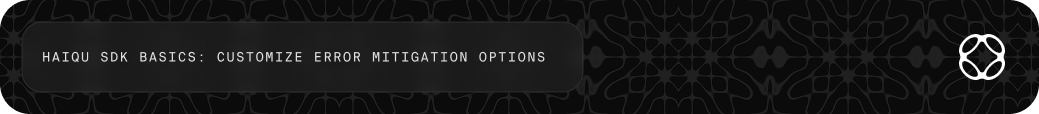

This notebook demonstrates how to selectively control individual error mitigation layers when executing quantum circuits with `haiqu.run(use_mitigation=True)`.

- By passing `error_mitigation_options` inside the `options` dictionary, you can **toggle individual mitigation layers** on or off
- Available options: **`dynamical_decoupling`**, **`readout_mitigation`**, **`noise_tailoring`**, and **`advanced_mitigation`**
- This lets you experiment with mitigation trade-offs and tailor the pipeline to your specific circuit and device

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `error_mitigation_options`

- **`dynamical_decoupling`** — Inserts pulse sequences into idle qubit time to suppress decoherence errors. Defaults to `True`. Skipped automatically on simulators.
- **`readout_mitigation`** — Corrects measurement (readout) errors. Uses Pauli twirling for observable tasks and a calibration-based method for sampling tasks. Defaults to `True`. Skipped automatically on simulators.
- **`noise_tailoring`** — Applies Pauli twirling to gate noise, converting coherent errors into stochastic ones that are easier to mitigate. Defaults to `False`.
- **`advanced_mitigation`** — Applies an advanced noise mitigation layer. Defaults to `True`.

All options default to `True` (except `noise_tailoring` which defaults to `False`) when `error_mitigation_options` is provided. You only need to specify the keys you want to change.

**Note:** this notebook assumes some basic knowledge of Haiqu SDK. Make sure to read through [`haiqu_run.ipynb`](./haiqu_run.ipynb) notebook first.

## Initialize the example

Import the necessary libraries, initialize the Haiqu SDK, and create a quantum circuit. We use a 10-qubit QFT adder circuit as the benchmark — it is deep enough to accumulate meaningful noise on real hardware.

In [ ]:
import qiskit
import pandas as pd
from haiqu.sdk import haiqu, set_haiqu_mpl_style

haiqu.login()
haiqu.init("Mitigation Options Tutorial")
set_haiqu_mpl_style()

In [2]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFTGate
import numpy as np

def build_adder_circuit(num_qubits, m, k):
    """
    Builds a quantum circuit that adds integer k to m using the QFT.

    Parameters:
    - num_qubits (int): Number of qubits.
    - m (int): Initial value.
    - k (int): Value to add.

    Returns:
    - QuantumCircuit implementing |m⟩ -> |m + k⟩ with measurement.
    - Binary strings for m and m+k (for verification).
    """
    m_binary = f"{m:0{num_qubits}b}"
    m_plus_k_binary = f"{m + k:0{num_qubits}b}"
    adder = QuantumCircuit(num_qubits)
    for i in range(num_qubits):
        if m_binary[i] == "1":
            adder.x(num_qubits - 1 - i)
    adder.compose(QFTGate(num_qubits), inplace=True)
    for i in range(num_qubits):
        adder.rz(k * np.pi / 2**i, num_qubits - i - 1)
    adder.compose(QFTGate(num_qubits).inverse(), inplace=True)
    adder.measure_all()
    return adder, m_binary, m_plus_k_binary

adder, m_binary, m_plus_k_binary = build_adder_circuit(num_qubits=10, m=343, k=19)
print(f"Target bitstring: |{m_binary}⟩ + {19} = |{m_plus_k_binary}⟩")
haiqu.draw(adder)

Target bitstring: |0101010111⟩ + 19 = |0101101010⟩


## Part 1: Sampling task — comparing mitigation options

We run the adder circuit under five different mitigation configurations and compare the success probability of measuring the correct bitstring. This illustrates the contribution of each individual layer.

To run on a particular quantum device, specify your credentials in the `options` parameter. We use `fake_torino` here, but you can replace it with a real device like `ibm_torino`.

In [3]:
device = haiqu.get_device("fake_torino")
options = {}

# Uncomment the following lines to run on the actual IBM Quantum device
# device = haiqu.get_device("ibm_torino")
# options = {
#     "ibm_quantum_token": "YOUR_IBM_QUANTUM_API_KEY",
#     "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE_ID",
# }

scenarios = [
    {
        "device": haiqu.get_device("aer_simulator"),
        "options": {},
        "use_mitigation": False,
        "description": "Ideal (aer_simulator)",
    },
    {
        "device": device,
        "options": {**options},
        "use_mitigation": False,
        "description": "No mitigation",
    },
    {
        "device": device,
        "options": {**options},
        "use_mitigation": True,
        "description": "Full mitigation (default)",
    },
    {
        "device": device,
        "options": {**options, "error_mitigation_options": {"advanced_mitigation": False}},
        "use_mitigation": True,
        "description": "DD + Readout only (no advanced mitigation)",
    },
    {
        "device": device,
        "options": {**options, "error_mitigation_options": {"dynamical_decoupling": False, "readout_mitigation": False}},
        "use_mitigation": True,
        "description": "Advanced only (no DD, no Readout)",
    },
    {
        "device": device,
        "options": {**options, "error_mitigation_options": {"noise_tailoring": True}},
        "use_mitigation": True,
        "description": "Full mitigation + noise tailoring",
    },
]

### Submit Sampling Jobs

In [4]:
saved_sampling_ids = {}
for scenario in scenarios:
    job = haiqu.run(
        adder,
        device=scenario["device"],
        options=scenario["options"],
        shots=8192,
        use_mitigation=scenario["use_mitigation"],
    )
    saved_sampling_ids[scenario["description"]] = job.id
    print(f"{scenario['description']}: {job.id}")

Ideal (aer_simulator): jb-6026aaa3-7322-48cb-97d4-059803ba9269
No mitigation: jb-306a979c-cc91-42ad-9049-daafe176d1b6
Full mitigation (default): jb-06a296ed-eded-43c9-93e9-d17ebcf717da
DD + Readout only (no advanced mitigation): jb-506e1a82-f903-44af-abfc-f9ea376b9449
Advanced only (no DD, no Readout): jb-68c0120a-0ac3-4e6c-a842-63bff5e410d3
Full mitigation + noise tailoring: jb-05a9868f-49ab-4e1b-b523-f22b4005313c


### Retrieve Sampling Results

Run this cell to get results once jobs are complete. You can close the notebook and come back later — just use the saved job IDs to retrieve results. We then compare the success probability (probability of the target bitstring) across different mitigation configurations from device runs.

**Note:** `job.result()` is a blocking call. If the job is not complete, it will wait until results are ready.

In [5]:
for description, job_id in saved_sampling_ids.items():
    job = haiqu.get_job(job_id)
    print(job.retrieve_status())

JobStatus.DONE
JobStatus.INITIALIZING
JobStatus.INITIALIZING
JobStatus.INITIALIZING
JobStatus.SUBMITTED
JobStatus.SUBMITTED


In [11]:
sampling_results = []
for name, job_id in saved_sampling_ids.items():
    job = haiqu.get_job(job_id)
    print(f"{name}: {job.retrieve_status()}")
    result = job.result()
    prob = result[0].get(m_plus_k_binary, 0)
    sampling_results.append({"description": name, "probability": prob})

baseline = next(r["probability"] for r in sampling_results if r["description"] == "No mitigation")
pd.DataFrame({
    "Configuration": [r["description"] for r in sampling_results],
    "Success Probability": [f'{r["probability"]:.1%}' for r in sampling_results],
    "vs No Mitigation (baseline)": [
        "—" if r["description"] in ("Ideal (aer_simulator)", "No mitigation")
        else f"{r['probability'] / baseline:.2f}x" if baseline > 0 else "N/A"
        for r in sampling_results
    ],
})

Ideal (aer_simulator): JobStatus.DONE
No mitigation: JobStatus.DONE
Full mitigation (default): JobStatus.DONE
DD + Readout only (no advanced mitigation): JobStatus.DONE
Advanced only (no DD, no Readout): JobStatus.DONE
Full mitigation + noise tailoring: JobStatus.DONE


,Configuration,Success Probability,vs No Mitigation (baseline)
0,Ideal (aer_simulator),100.0%,—
1,No mitigation,20.0%,—
2,Full mitigation (default),86.9%,4.35x
3,DD + Readout only (no advanced mitigation),18.0%,0.90x
4,"Advanced only (no DD, no Readout)",78.9%,3.95x
5,Full mitigation + noise tailoring,75.3%,3.77x


## Part 2: Expectation value task — mitigation options with observables

When observables are provided, the mitigation pipeline switches to an observable-specific mode. Here we measure the `ZZ` expectation value of a Bell state, which should be `1.0` for an ideal device. We compare how different mitigation options recover this value under noise.

In [7]:
from qiskit.quantum_info import SparsePauliOp

bell = qiskit.QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

observable = SparsePauliOp("ZZ")  # Ideal expectation value: 1.0

### Submit Observable Jobs

In [8]:
saved_observable_ids = {}
for scenario in scenarios:
    job = haiqu.run(
        bell,
        observables=observable,
        device=scenario["device"],
        options=scenario["options"],
        shots=8192,
        use_mitigation=scenario["use_mitigation"],
    )
    saved_observable_ids[scenario["description"]] = job.id
    print(f"{scenario['description']}: {job.id}")

Ideal (aer_simulator): jb-01c28075-2d58-4d02-84f9-80321e9d5ef0
No mitigation: jb-b608cae0-b834-4c1d-89a0-236533139291
Full mitigation (default): jb-be0bc96c-1c61-4d6b-9d6a-57965206c3f2
DD + Readout only (no advanced mitigation): jb-af83105f-b92f-473a-bac5-6fb6d79afc42
Advanced only (no DD, no Readout): jb-941e88b9-ed1f-4f49-8481-66a2f0da9130
Full mitigation + noise tailoring: jb-7175e893-9e69-4ee1-860d-ab2e67cbb86a


### Retrieve Observable Results

In this case, we compare the mitigated expectation value to the ideal value of 1.0. We can see how close each mitigation configuration gets us to the ideal result by comparing the absolute difference to the target expectation value.

In [10]:
observable_results = []
for name, job_id in saved_observable_ids.items():
    job = haiqu.get_job(job_id)
    print(f"{name}: {job.retrieve_status()}")
    result = job.result()
    expval = result[0][0]  # <ZZ> expectation value
    observable_results.append({"description": name, "expval": expval})

pd.DataFrame({
    "Configuration": [r["description"] for r in observable_results],
    "<ZZ> (ideal = 1.0)": [f'{r["expval"]:.4f}' for r in observable_results],
    "Error |1.0 - <ZZ>|": [f'{abs(1.0 - r["expval"]):.4f}' for r in observable_results],
})

Ideal (aer_simulator): JobStatus.DONE
No mitigation: JobStatus.DONE
Full mitigation (default): JobStatus.DONE
DD + Readout only (no advanced mitigation): JobStatus.DONE
Advanced only (no DD, no Readout): JobStatus.DONE
Full mitigation + noise tailoring: JobStatus.DONE


,Configuration,<ZZ> (ideal = 1.0),Error |1.0 - <ZZ>|
0,Ideal (aer_simulator),1.0000,0.0000
1,No mitigation,0.9565,0.0435
2,Full mitigation (default),1.0026,0.0026
3,DD + Readout only (no advanced mitigation),0.9556,0.0444
4,"Advanced only (no DD, no Readout)",1.0010,0.0010
5,Full mitigation + noise tailoring,1.0023,0.0023


> **💡 Good to Know:** The mitigation pipeline adapts automatically based on whether observables are present. For sampling tasks, `advanced_mitigation` uses FFT-based noise correction. For observable tasks, it uses ODR (Observable-Dependent Rescaling). You can find more details in the [noise mitigation documentation](https://docs.haiqu.ai/core_features/error_shield).

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

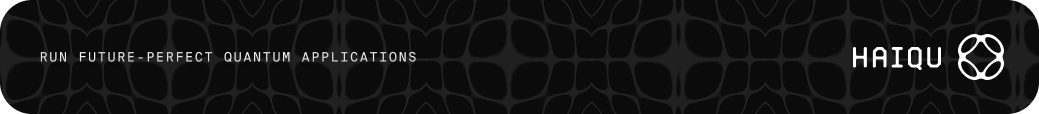